In [ ]:
import tensorflow as tf
from tensorflow import keras 
import numpy as np
import matplotlib.pyplot as plt
 
# keras의 데이터셋의 패션 MNIST 데이터를 학습용, 테스트 데이터로 구분
fashion_mnist = keras.datasets.fashion_mnist 
(train_images, train_labels), (test_images, test_labels) =\
fashion_mnist.load_data()


32768/29515 [=================================] - 0s 0us/step

40960/29515 [=========================================] - 0s 0us/step


26427392/26421880 [==============================] - 0s 0us/step

26435584/26421880 [==============================] - 0s 0us/step


16384/5148 [===============================================================================================] - 0s 0us/step


4423680/4422102 [==============================] - 0s 0us/step

4431872/4422102 [==============================] - 0s 0us/step


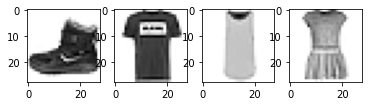

In [ ]:
fig = plt.figure()
ax1 = fig.add_subplot(1, 4, 1)
ax2 = fig.add_subplot(1, 4, 2)
ax3 = fig.add_subplot(1, 4, 3)
ax4 = fig.add_subplot(1, 4, 4)

ax1.imshow(train_images[0], cmap='Greys') # 첫 번째 훈련용 데이터
ax2.imshow(train_images[1], cmap='Greys') # 두 번째 훈련용 데이터
ax3.imshow(train_images[2], cmap='Greys') # 세 번째 훈련용 데이터
ax4.imshow(train_images[3], cmap='Greys') # 네 번째 훈련용 데이터

In [ ]:
print(train_labels[:4])

[9 0 0 3]


In [ ]:
mnist_lbl = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
             'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle_boot']

labels = train_labels[:4]
for i in labels:
    print('{} : {}'.format(i, mnist_lbl[i]))

9 : Ankle_boot

0 : T-shirt

0 : T-shirt

3 : Dress


Text(0, 0, 'Dress')

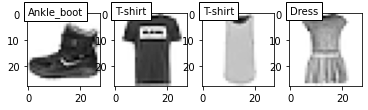

In [ ]:
fig = plt.figure()
ax1 = fig.add_subplot(1, 4, 1)
ax2 = fig.add_subplot(1, 4, 2)
ax3 = fig.add_subplot(1, 4, 3)
ax4 = fig.add_subplot(1, 4, 4)

ax1.imshow(train_images[0], cmap='Greys') # 첫 번째 훈련용 데이터
ax2.imshow(train_images[1], cmap='Greys') # 두 번째 훈련용 데이터
ax3.imshow(train_images[2], cmap='Greys') # 세 번째 훈련용 데이터
ax4.imshow(train_images[3], cmap='Greys') # 네 번째 훈련용 데이터

ax1.text(0, 0, mnist_lbl[train_labels[0]], bbox={'facecolor': 'white'})
ax2.text(0, 0, mnist_lbl[train_labels[1]], bbox={'facecolor': 'white'})
ax3.text(0, 0, mnist_lbl[train_labels[2]], bbox={'facecolor': 'white'})
ax4.text(0, 0, mnist_lbl[train_labels[3]], bbox={'facecolor': 'white'})

In [ ]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

train_images, test_images = train_images / 255, test_images / 255
model.fit(train_images, train_labels, epochs=10)

test_loss, test_acc = model.evaluate(test_images, test_labels,\
                                     verbose=2)
print('\n테스트 정확도:', test_acc)

Epoch 1/10

1875/1875 [==============================] - 8s 4ms/step - loss: 0.4805 - accuracy: 0.8282

Epoch 2/10

1875/1875 [==============================] - 8s 4ms/step - loss: 0.3621 - accuracy: 0.8674

Epoch 3/10

1875/1875 [==============================] - 8s 4ms/step - loss: 0.3280 - accuracy: 0.8778

Epoch 4/10

1875/1875 [==============================] - 8s 4ms/step - loss: 0.3040 - accuracy: 0.8865

Epoch 5/10

1875/1875 [==============================] - 8s 4ms/step - loss: 0.2876 - accuracy: 0.8925

Epoch 6/10

1875/1875 [==============================] - 8s 4ms/step - loss: 0.2721 - accuracy: 0.8968

Epoch 7/10

1875/1875 [==============================] - 8s 4ms/step - loss: 0.2590 - accuracy: 0.9024

Epoch 8/10

1875/1875 [==============================] - 8s 4ms/step - loss: 0.2489 - accuracy: 0.9060

Epoch 9/10

1875/1875 [==============================] - 8s 4ms/step - loss: 0.2376 - accuracy: 0.9100

Epoch 10/10

1875/1875 [==============================] - 8s 4ms

In [ ]:
model.summary()

Model: "sequential"

_________________________________________________________________

Layer (type)                 Output Shape              Param #   


flatten (Flatten)            (None, 784)               0         

_________________________________________________________________

dense (Dense)                (None, 256)               200960    

_________________________________________________________________

dense_1 (Dense)              (None, 128)               32896     

_________________________________________________________________

dense_2 (Dense)              (None, 100)               12900     

_________________________________________________________________

dense_3 (Dense)              (None, 10)                1010      


Total params: 247,766

Trainable params: 247,766

Non-trainable params: 0

_________________________________________________________________


In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

# 패션 MNIST 데이터는 keras의 데이터셋에 있으며, 이를 학습용, 테스트 데이터로 구분하자
fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

In [ ]:
train_images = train_images[:, :, :, np.newaxis]
test_images = test_images[:, :, :, np.newaxis]
train_images, test_images = train_images / 255, test_images / 255

In [ ]:
model = keras.models.Sequential( [
    keras.layers.Conv2D(input_shape = (28, 28, 1),
                        kernel_size = (3,3), padding = 'same', 
                        filters = 32),
    keras.layers.MaxPooling2D((2, 2), strides=2),
    keras.layers.Conv2D(kernel_size = (3,3), padding ='same', 
                        filters = 64),
    keras.layers.MaxPooling2D((2, 2), strides=2),
    keras.layers.Conv2D(kernel_size = (3,3), padding = 'same', 
                        filters = 32),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation = 'relu'),
    keras.layers.Dense(32, activation = 'relu'),
    keras.layers.Dense(10, activation = 'softmax'),
])

In [ ]:
model.summary()

Model: "sequential_1"

_________________________________________________________________

Layer (type)                 Output Shape              Param #   


conv2d (Conv2D)              (None, 28, 28, 32)        320       

_________________________________________________________________

max_pooling2d (MaxPooling2D) (None, 14, 14, 32)        0         

_________________________________________________________________

conv2d_1 (Conv2D)            (None, 14, 14, 64)        18496     

_________________________________________________________________

max_pooling2d_1 (MaxPooling2 (None, 7, 7, 64)          0         

_________________________________________________________________

conv2d_2 (Conv2D)            (None, 7, 7, 32)          18464     

_________________________________________________________________

flatten_1 (Flatten)          (None, 1568)              0         

_________________________________________________________________

dense_4 (Dense)              (None, 12

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
hist = model.fit(train_images, train_labels,
                 epochs=5, validation_split=0.25)

Epoch 1/5

1407/1407 [==============================] - 67s 48ms/step - loss: 0.4602 - accuracy: 0.8314 - val_loss: 0.3659 - val_accuracy: 0.8668

Epoch 2/5

1407/1407 [==============================] - 68s 49ms/step - loss: 0.3034 - accuracy: 0.8892 - val_loss: 0.2939 - val_accuracy: 0.8920

Epoch 3/5

1407/1407 [==============================] - 71s 50ms/step - loss: 0.2548 - accuracy: 0.9067 - val_loss: 0.2816 - val_accuracy: 0.8955

Epoch 4/5

1407/1407 [==============================] - 69s 49ms/step - loss: 0.2230 - accuracy: 0.9170 - val_loss: 0.2564 - val_accuracy: 0.9061

Epoch 5/5

1407/1407 [==============================] - 69s 49ms/step - loss: 0.1989 - accuracy: 0.9257 - val_loss: 0.2686 - val_accuracy: 0.9084


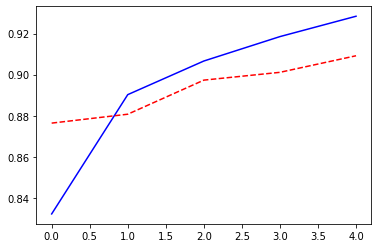

In [ ]:
plt.plot(hist.history['accuracy'], 'b-')
plt.plot(hist.history['val_accuracy'], 'r--')

In [ ]:
test_loss, test_acc = model.evaluate(test_images,  test_labels,\
                                     verbose=2)
print('테스트 정확도:', test_acc)

313/313 - 3s - loss: 0.2762 - accuracy: 0.9040

테스트 정확도: 0.9039999842643738


In [ ]:
mnist_lbl = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
             'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle_boot']

images = test_images[:25]
pred = np.argmax(model.predict(images), axis=1)
print('예측값 =', pred)
print('실제값 =', test_labels[:25])

예측값 = [9 2 1 1 6 1 4 6 5 7 4 5 8 3 4 1 2 4 8 0 2 5 7 5 1]

실제값 = [9 2 1 1 6 1 4 6 5 7 4 5 7 3 4 1 2 4 8 0 2 5 7 9 1]
